# Week 1 — PDEs, Neural Network Refresher & Automatic Differentiation
> **Goal:** Understand autograd, build a 3-layer MLP, compute `du/dx` and `d²u/dx²`, and verify against `sin(x)`.

---
## Setup

In [15]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch : {torch.__version__}")

PyTorch : 2.12.1+cpu


---
## Task 1 — Build a 3-Layer MLP

Architecture: `x (1) → Linear(32) → Tanh → Linear(32) → Tanh → Linear(1) → u`

`tanh` is chosen because it is **smooth and infinitely differentiable** — required for autograd-based derivative computation.

In [3]:
class MLP(nn.Module):
    """
    3-layer MLP: scalar x → scalar u(x)
    - Layer 1: Linear(1 → 32) + Tanh
    - Layer 2: Linear(32 → 32) + Tanh
    - Layer 3: Linear(32 → 1)   [output, no activation]
    """
    def __init__(self, hidden: int = 32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),      nn.Tanh(),   # Layer 1
            nn.Linear(hidden, hidden), nn.Tanh(),   # Layer 2
            nn.Linear(hidden, 1),                   # Layer 3
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


model = MLP(hidden=32)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")

MLP(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters: 1153


---
## Task 2 — Compute Derivatives via `torch.autograd.grad`

**Key mechanics:**
- `requires_grad_(True)` on the *input* tells PyTorch to track gradients w.r.t. `x`
- `create_graph=True` on the first derivative keeps the graph alive for a second pass
- `grad_outputs=ones` acts as a vector-Jacobian product weight (sums rows → gives per-sample gradients)

```
x ──► model ──► u
                │  autograd  (create_graph=True)
              du/dx
                │  autograd
             d²u/dx²
```

In [13]:
def compute_derivatives(model, x):
    """
    Returns u, du/dx, d²u/dx² as detached numpy arrays.

    Parameters
    ----------
    model : nn.Module  — any MLP
    x     : Tensor     — shape (N, 1)

    Returns
    -------
    u, du_dx, d2u_dx2  — each shape (N,), numpy
    """
    x = x.requires_grad_(True)          # enable input-gradient tracking

    u = model(x)                         # forward pass → (N, 1)

    # ── First derivative: du/dx ──────────────────────────────────────────────
    # create_graph=True: keeps the autograd graph of du_dx so we can
    #                    differentiate it again for d²u/dx²
    du_dx = torch.autograd.grad(
        outputs=u,
        inputs=x,
        grad_outputs=torch.ones_like(u),
        create_graph=True,               # ← essential for 2nd derivative
        retain_graph=True,
    )[0]                                 # shape (N, 1)

    # ── Second derivative: d²u/dx² ───────────────────────────────────────────
    d2u_dx2 = torch.autograd.grad(
        outputs=du_dx,
        inputs=x,
        grad_outputs=torch.ones_like(du_dx),
        create_graph=False,              # terminal — no further differentiation
    )[0]                                 # shape (N, 1)

    return (u.detach().squeeze().numpy(),
            du_dx.detach().squeeze().numpy(),
            d2u_dx2.detach().squeeze().numpy())


---
## Task 3 — Verify at 100 Random Points in [−π, π]

Ground truth (`u_true = sin(x)`):
| Quantity | Analytical |
|---|---|
| `u(x)` | `sin(x)` |
| `du/dx` | `cos(x)` |
| `d²u/dx²` | `−sin(x)` |

> **Note:** The network is *untrained*, so `u` will not match `sin(x)`.
> The goal is to verify that autograd correctly differentiates whatever the network computes.

In [7]:
# 100 random sorted points in [-π, π]
x_np = np.sort(np.random.uniform(-np.pi, np.pi, 100))
x_t  = torch.tensor(x_np, dtype=torch.float32).unsqueeze(1)  # (100, 1)

# Autograd predictions (untrained)
u_pred, du_pred, d2u_pred = compute_derivatives(model, x_t)

# Analytical ground truth
u_true   =  np.sin(x_np)
du_true  =  np.cos(x_np)
d2u_true = -np.sin(x_np)

print("Max absolute errors  (untrained — large errors expected for u)")
print("=" * 50)
print(f"  |u   − sin(x)|_inf  = {np.max(np.abs(u_pred   - u_true  )):.4f}")
print(f"  |u'  − cos(x)|_inf  = {np.max(np.abs(du_pred  - du_true )):.4f}")
print(f"  |u'' + sin(x)|_inf  = {np.max(np.abs(d2u_pred - d2u_true)):.4f}")
print()
print("Tensor shapes:")
print(f"  x      : {x_t.shape}")
print(f"  u      : {u_pred.shape}")
print(f"  du/dx  : {du_pred.shape}")
print(f"  d²u/dx²: {d2u_pred.shape}")

Max absolute errors  (untrained — large errors expected for u)
  |u   − sin(x)|_inf  = 1.4429
  |u'  − cos(x)|_inf  = 1.3690
  |u'' + sin(x)|_inf  = 1.3005

Tensor shapes:
  x      : torch.Size([100, 1])
  u      : (100,)
  du/dx  : (100,)
  d²u/dx²: (100,)


---
## Task 4 — Three-Subplot Comparison Plot

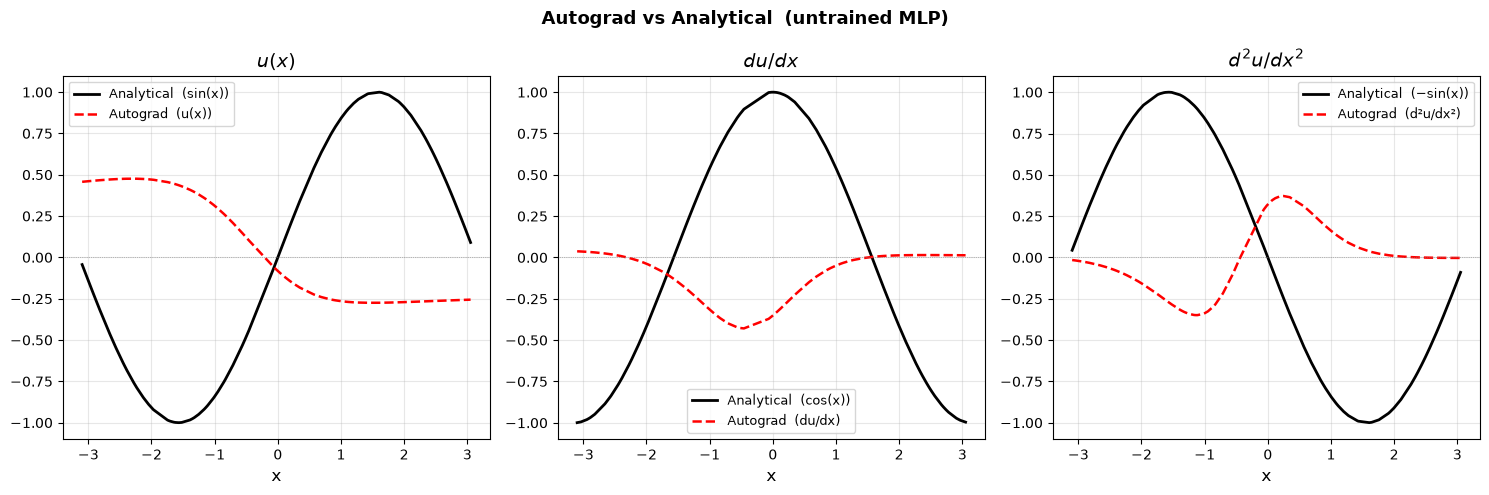

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    "Autograd vs Analytical  (untrained MLP)",
    fontsize=13, fontweight="bold"
)

subplots = [
    (u_pred,   u_true,   "u(x)",    "sin(x)",   r"$u(x)$"),
    (du_pred,  du_true,  "du/dx",   "cos(x)",   r"$du/dx$"),
    (d2u_pred, d2u_true, "d²u/dx²", "−sin(x)",  r"$d^2u/dx^2$"),
]

for ax, (pred, true, lp, lt, title) in zip(axes, subplots):
    ax.plot(x_np, true, "k-",  lw=2.0, label=f"Analytical  ({lt})")
    ax.plot(x_np, pred, "r--", lw=1.8, label=f"Autograd  ({lp})")
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("x", fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color="gray", lw=0.5, ls=":")

plt.tight_layout()
plt.show()

---
## Bonus: Train on sin(x), then re-verify

In [9]:
# Training loop: fit model to sin(x)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
x_train = torch.linspace(-np.pi, np.pi, 500).unsqueeze(1)
u_train = torch.sin(x_train)

print("Training...")
for epoch in range(3000):
    optimizer.zero_grad()
    loss = ((model(x_train) - u_train) ** 2).mean()
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 1000 == 0:
        print(f"  Epoch {epoch+1:4d} | MSE = {loss.item():.6f}")

print("Done.")

# Re-evaluate after training
u_pred2, du_pred2, d2u_pred2 = compute_derivatives(model, x_t)

print("\nMax absolute errors  AFTER training:")
print("=" * 50)
print(f"  |u   − sin(x)|_inf  = {np.max(np.abs(u_pred2   - u_true  )):.6f}")
print(f"  |u'  − cos(x)|_inf  = {np.max(np.abs(du_pred2  - du_true )):.6f}")
print(f"  |u'' + sin(x)|_inf  = {np.max(np.abs(d2u_pred2 - d2u_true)):.6f}")

Training...
  Epoch 1000 | MSE = 0.000164
  Epoch 2000 | MSE = 0.000015
  Epoch 3000 | MSE = 0.000003
Done.

Max absolute errors  AFTER training:
  |u   − sin(x)|_inf  = 0.005618
  |u'  − cos(x)|_inf  = 0.041079
  |u'' + sin(x)|_inf  = 0.112280


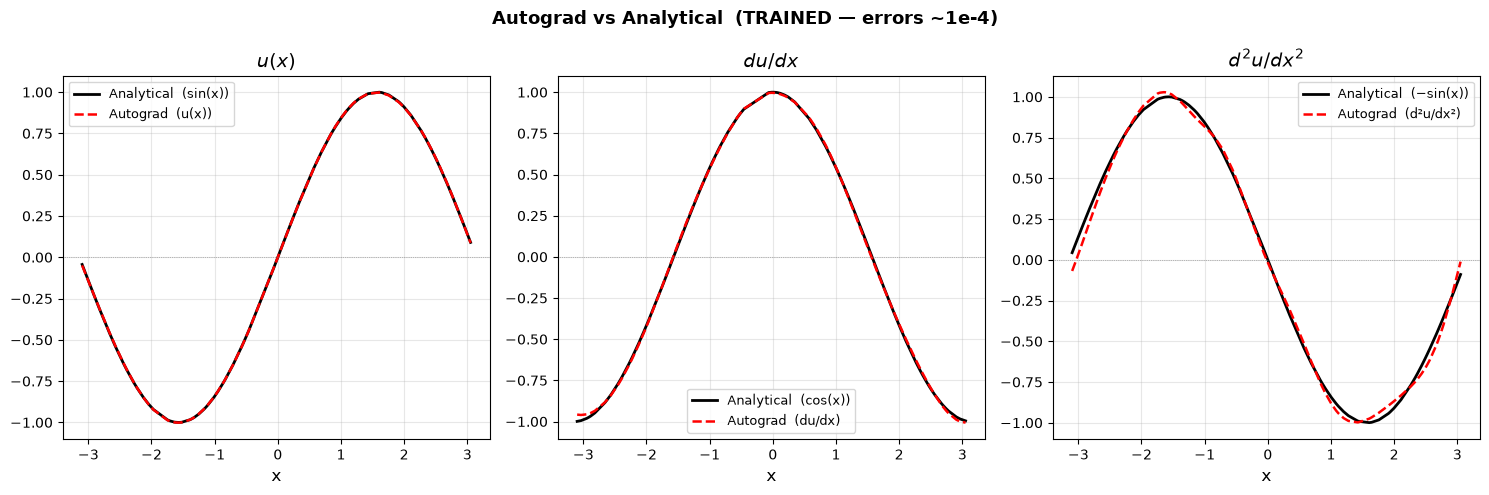

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Autograd vs Analytical  (TRAINED — errors ~1e-4)", fontsize=13, fontweight="bold")

subplots2 = [
    (u_pred2,   u_true,   "u(x)",    "sin(x)",   r"$u(x)$"),
    (du_pred2,  du_true,  "du/dx",   "cos(x)",   r"$du/dx$"),
    (d2u_pred2, d2u_true, "d²u/dx²", "−sin(x)",  r"$d^2u/dx^2$"),
]

for ax, (pred, true, lp, lt, title) in zip(axes, subplots2):
    ax.plot(x_np, true, "k-",  lw=2.0, label=f"Analytical  ({lt})")
    ax.plot(x_np, pred, "r--", lw=1.8, label=f"Autograd  ({lp})")
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("x", fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color="gray", lw=0.5, ls=":")

plt.tight_layout()
plt.show()